# Embeddings & the inspection API

`betula-cluster` shines on **embedding** data — where the cluster signal is a *direction* and
magnitude is noise — and it gives you the **structure** of the dataset, not just labels: outlier
scores, near-duplicate groups, representatives, and the microcluster/cluster geometry. All of it
reuses the CF-tree it already built (no extra passes).

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import betula_cluster
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook", palette="deep")


def direction_clusters(n=12_000, k=6, sigma=0.06, seed=0):
    """2-D vectors whose cluster is the angle; radius (magnitude) is lognormal noise."""
    rng = np.random.default_rng(seed)
    angles = np.linspace(0, 2 * np.pi, k, endpoint=False)
    per = n // k
    xs, ys = [], []
    for c, a in enumerate(angles):
        th = a + sigma * rng.standard_normal(per)
        r = rng.lognormal(0.0, 0.7, per)  # wide magnitude spread
        xs.append(np.c_[r * np.cos(th), r * np.sin(th)])
        ys += [c] * per
    x = np.vstack(xs)
    perm = rng.permutation(len(x))
    return x[perm], np.array(ys)[perm]


X, y = direction_clusters()
print("X:", X.shape)

X: (12000, 2)


## Raw Euclidean fails; `normalize=True` recovers the direction clusters

On varying-norm vectors, raw Euclidean distance is dominated by magnitude. `normalize=True` maps
rows onto the unit sphere, where squared-Euclidean is monotone in cosine — so the tree clusters by
angle.

raw ARI       = 0.253
normalize ARI = 1.000


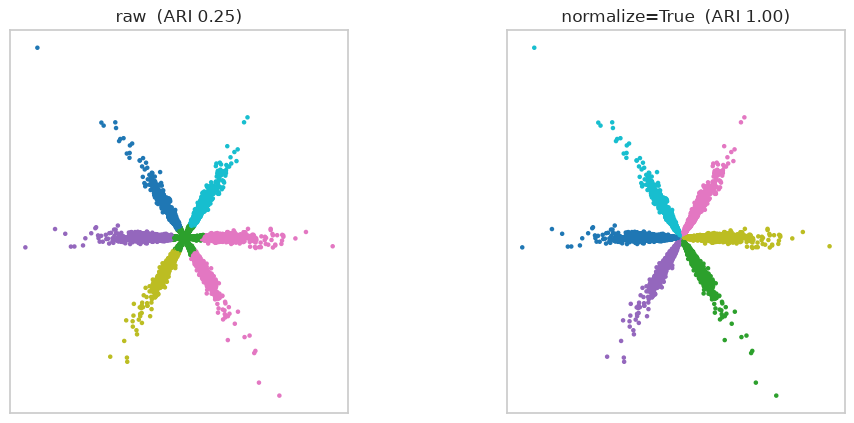

In [2]:
from sklearn.metrics import adjusted_rand_score as ari

lab_raw = np.asarray(betula_cluster.fit_predict(X, 6, feature="diagonal", method="kmeans"))
lab_norm = np.asarray(
    betula_cluster.fit_predict(X, 6, feature="diagonal", method="kmeans", normalize=True)
)
print(f"raw ARI       = {ari(y, lab_raw):.3f}")
print(f"normalize ARI = {ari(y, lab_norm):.3f}")

fig, ax = plt.subplots(1, 2, figsize=(11, 4.4))
for a, (lab, name) in zip(ax, [(lab_raw, "raw"), (lab_norm, "normalize=True")], strict=True):
    a.scatter(X[:, 0], X[:, 1], c=lab, s=5, cmap="tab10")
    a.set_title(f"{name}  (ARI {ari(y, lab):.2f})")
    a.set_aspect("equal")
    a.set_xticks([])
    a.set_yticks([])
fig.tight_layout()
plt.show()

## The estimator keeps the model — inspect its structure

In [3]:
est = betula_cluster.Betula(n_clusters=6, feature="diagonal", method="kmeans", normalize=True)
est.fit(X)
est.summary()

{'n_samples': 12000,
 'n_microclusters': 1691,
 'mean_microcluster_radius': 0.00023036728925435076,
 'n_clusters': 6,
 'largest_cluster_size': 2000,
 'mean_cluster_radius': 0.059430775667648726}

## Outlier scores

`outlier_scores(X)` = distance to the assigned cluster centroid ÷ that cluster's RMS radius. We
inject a few far points and color every point by its score.

top-3 outlier row indices: [12002, 12001, 11915] (injected were [12000, 12001, 12002] )


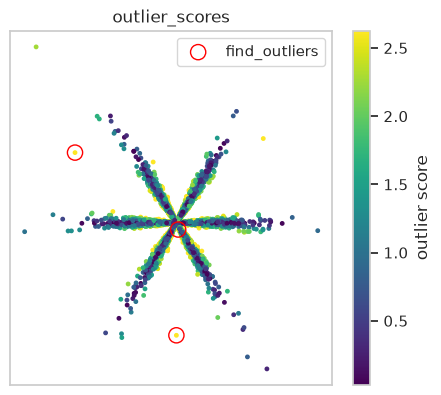

In [4]:
Xo = np.vstack([X, np.array([[6.0, 6.0], [-7.0, 5.0], [0.0, -8.0]])])
scores = est.outlier_scores(Xo)
top = est.find_outliers(Xo, top_k=3)
print("top-3 outlier row indices:", top.tolist(), "(injected were", list(range(len(X), len(Xo))), ")")

plt.figure(figsize=(5.2, 4.6))
sc = plt.scatter(Xo[:, 0], Xo[:, 1], c=np.clip(scores, 0, np.percentile(scores, 99)), s=6, cmap="viridis")
plt.scatter(Xo[top, 0], Xo[top, 1], facecolors="none", edgecolors="red", s=120, label="find_outliers")
plt.colorbar(sc, label="outlier score")
plt.legend()
plt.title("outlier_scores")
plt.xticks([])
plt.yticks([])
plt.show()

## Near-duplicates and representatives

`find_near_duplicates` returns groups of points sharing a microcluster tighter than a radius;
`sample_representatives` returns the points nearest each cluster centroid (a compact summary set).

In [5]:
dups = np.repeat(X[:1], 5, axis=0)  # 5 exact copies of one row
Xd = np.vstack([X, dups])
groups = est.find_near_duplicates(Xd, radius=0.05)
print(f"near-duplicate groups found: {len(groups)}; largest has {max(len(g) for g in groups)} rows")

reps = est.sample_representatives(X, k=3)
print("representatives per cluster:", {c: idx.tolist() for c, idx in list(reps.items())[:3]}, "...")

near-duplicate groups found: 1231; largest has 61 rows
representatives per cluster: {0: [541, 6608, 9970], 1: [1070, 3092, 10548], 2: [9624, 9448, 3584]} ...


## Microcluster geometry

The compressed view: every leaf is a microcluster with a centroid, mass, and radius.

1691 microclusters compress 12000 points


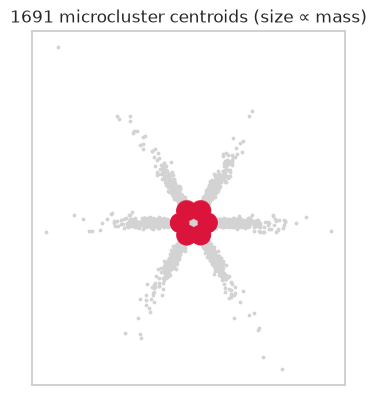

In [6]:
centers = est.microcluster_centers_
weights = est.microcluster_weights_
print(f"{est.n_leaves_} microclusters compress {len(X)} points")

plt.figure(figsize=(5, 4.6))
plt.scatter(X[:, 0], X[:, 1], s=3, c="lightgray")
plt.scatter(centers[:, 0], centers[:, 1], s=10 + 200 * weights / weights.max(), c="crimson", alpha=0.6)
plt.title(f"{est.n_leaves_} microcluster centroids (size ∝ mass)")
plt.gca().set_aspect("equal")
plt.xticks([])
plt.yticks([])
plt.show()